# DATA 602 Assignment 8: Matplotlib and Seaborn Visualization

**Kevin Martin**  
**DATA 602**  
**Spring 2026**

<a href="https://colab.research.google.com/github/data602sps/assignments/blob/master/05_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Introduction

For this assignment, I selected the NYC 311 Service Requests dataset from NYC Open Data. This dataset contains information about complaints submitted by residents, including complaint type, location, date, and status.

I chose this dataset because I have personal experience using the NYC 311 system and wanted to better understand how complaints are reported and handled. This dataset provides an opportunity to explore real-world data and identify patterns in service requests over time.

Dataset Source:
https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data




______________
# Data Exploration



In [2]:
import pandas as pd

# Load dataset (sample to keep it manageable)
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

# Read a subset (limit rows so it runs fast)
df = pd.read_csv(url, nrows=5000)

# Display first few rows
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,68835566,2026-05-01T02:57:27.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11222.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68835736,2026-05-01T02:06:03.000,NaN,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,NaN,Street/Sidewalk,11230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.629939,-73.958407,POINT (-73.958407219339 40.629939362413)
2,68837391,2026-05-01T02:05:40.000,NaN,DOHMH,Department of Health and Mental Hygiene,Rodent,Condition Attracting Rodents,Loose or Improperly Stored Garbage or Food,3+ Family Apt. Building,10452.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.831527,-73.928863,POINT (-73.928863032215 40.831527104823)
3,68837077,2026-05-01T02:05:37.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,Club/Bar/Restaurant,11238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.683347,-73.966212,POINT (-73.966212377137 40.683347123333)
4,68845286,2026-05-01T02:05:24.000,NaN,NYPD,New York City Police Department,Noise - Vehicle,Car/Truck Music,NaN,Street/Sidewalk,11211.0,...,Car,NaN,NaN,NaN,NaN,NaN,NaN,40.715225,-73.944430,POINT (-73.944429912719 40.715224624993)


In [3]:
# Check dataset shape (rows, columns)
df.shape

(1000, 44)

In [4]:
# View column names
df.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'descriptor_2', 'location_type',
       'incident_zip', 'incident_address', 'street_name', 'cross_street_1',
       'cross_street_2', 'intersection_street_1', 'intersection_street_2',
       'address_type', 'city', 'landmark', 'facility_type', 'status',
       'due_date', 'resolution_description', 'resolution_action_updated_date',
       'community_board', 'council_district', 'police_precinct', 'bbl',
       'borough', 'x_coordinate_state_plane', 'y_coordinate_state_plane',
       'open_data_channel_type', 'park_facility_name', 'park_borough',
       'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location',
       'bridge_highway_name', 'bridge_highway_direction', 'road_ramp',
       'bridge_highway_segment', 'latitude', 'longitude', 'location'],
      dtype='object')

In [5]:
# Select important columns
df = df[['created_date', 'closed_date', 'complaint_type', 'borough', 'status']]

# Check result
df.head()

,created_date,closed_date,complaint_type,borough,status
0,2026-05-01T02:57:27.000,NaN,Street Condition,BROOKLYN,Open
1,2026-05-01T02:06:03.000,NaN,Illegal Parking,BROOKLYN,In Progress
2,2026-05-01T02:05:40.000,NaN,Rodent,BRONX,In Progress
3,2026-05-01T02:05:37.000,NaN,Noise - Commercial,BROOKLYN,In Progress
4,2026-05-01T02:05:24.000,NaN,Noise - Vehicle,BROOKLYN,In Progress


In [7]:
# Summary statistics
df.describe(include='all')

# Check missing values
df.isnull().sum()

,0
created_date,0
closed_date,531
complaint_type,0
borough,0
status,0


# Data Wrangling



In [8]:
# Convert dates to datetime format
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# Create a new column for year
df['year'] = df['created_date'].dt.year

# Check result
df.head()

,created_date,closed_date,complaint_type,borough,status,year
0,2026-05-01 02:57:27,NaT,Street Condition,BROOKLYN,Open,2026
1,2026-05-01 02:06:03,NaT,Illegal Parking,BROOKLYN,In Progress,2026
2,2026-05-01 02:05:40,NaT,Rodent,BRONX,In Progress,2026
3,2026-05-01 02:05:37,NaT,Noise - Commercial,BROOKLYN,In Progress,2026
4,2026-05-01 02:05:24,NaT,Noise - Vehicle,BROOKLYN,In Progress,2026


# Visualizations



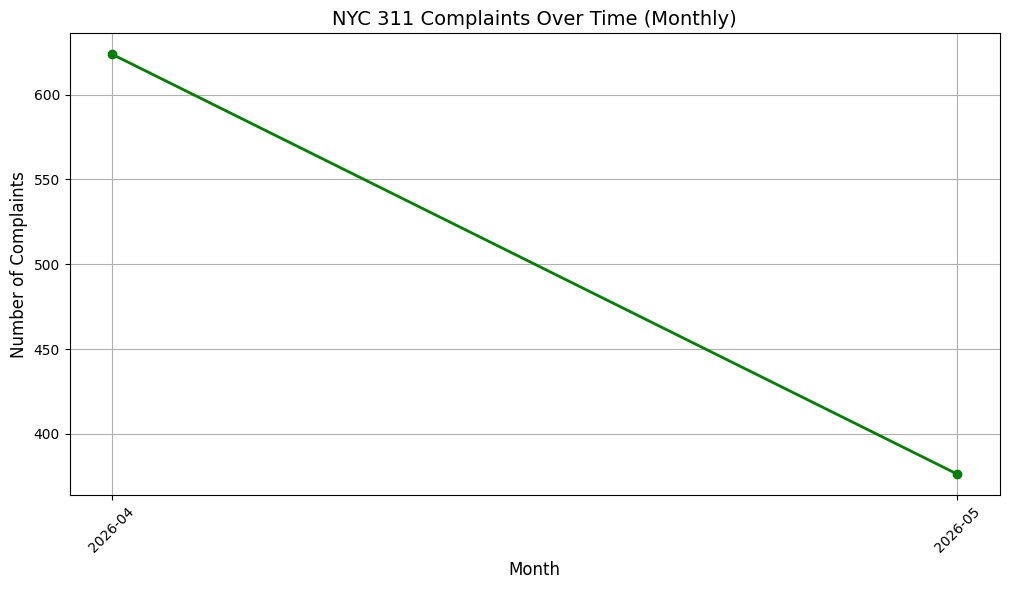

In [10]:
# Create month column
df['month'] = df['created_date'].dt.to_period('M')

# Group by month
complaints_per_month = df.groupby('month').size()

# Plot again
plt.figure(figsize=(12,6))
plt.plot(complaints_per_month.index.astype(str), complaints_per_month.values,
         marker='o', color='green', linewidth=2)

# Improve labels
plt.title("NYC 311 Complaints Over Time (Monthly)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

# Rotate x-axis for readability
plt.xticks(rotation=45)

# Grid
plt.grid(True)

plt.show()

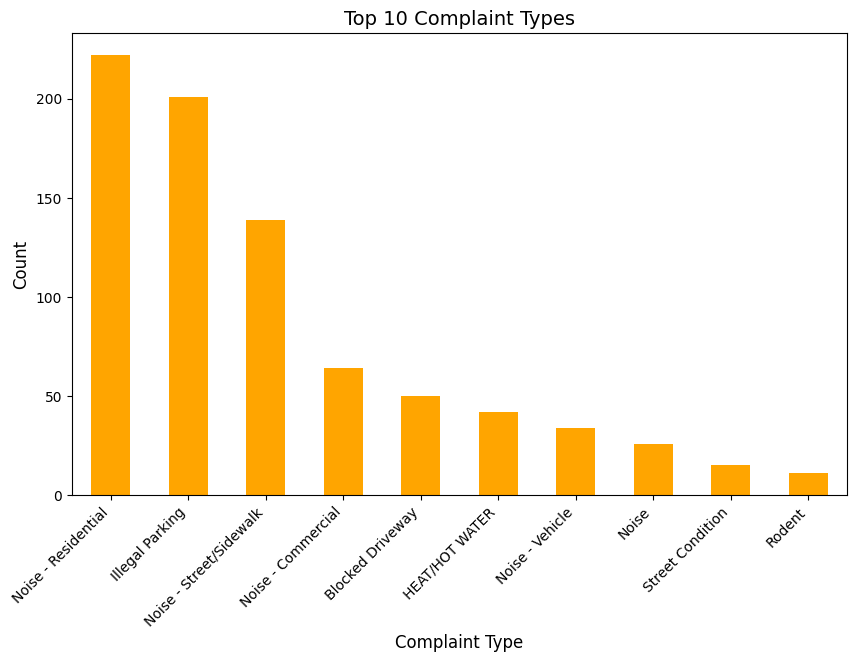

In [11]:
# Get top 10 complaint types
top_complaints = df['complaint_type'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
top_complaints.plot(kind='bar', color='orange')

# Add labels and title
plt.title("Top 10 Complaint Types", fontsize=14)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.show()

### Matplotlib Visualizations

The first Matplotlib visualization shows NYC 311 complaints over time by month. This line chart helps show whether complaints are increasing or decreasing during the time period included in the dataset. I used a title, x-axis label, y-axis label, marker, line color, line width, grid, and rotated x-axis labels to make the chart easier to read.

The second Matplotlib visualization shows the top 10 complaint types in the dataset. This bar chart makes it easier to compare which complaint categories appear most often. I used a title, axis labels, color, rotated labels, and figure sizing to make the chart more readable.

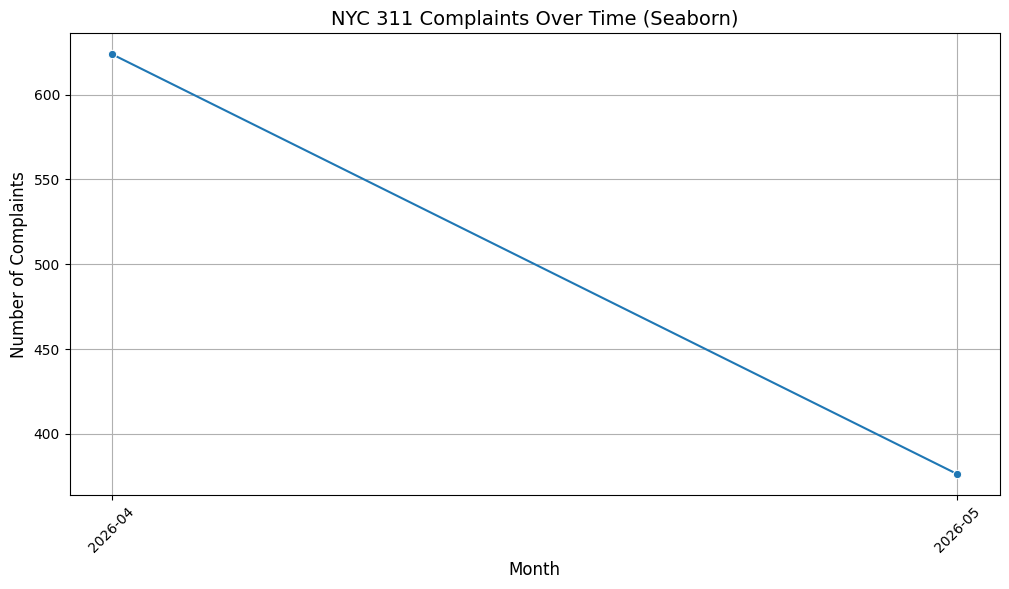

In [12]:
import seaborn as sns

# Convert monthly complaints into a dataframe for seaborn
monthly_df = complaints_per_month.reset_index()
monthly_df.columns = ['month', 'count']
monthly_df['month'] = monthly_df['month'].astype(str)

# Create seaborn line plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_df, x='month', y='count', marker='o')

plt.title("NYC 311 Complaints Over Time (Seaborn)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

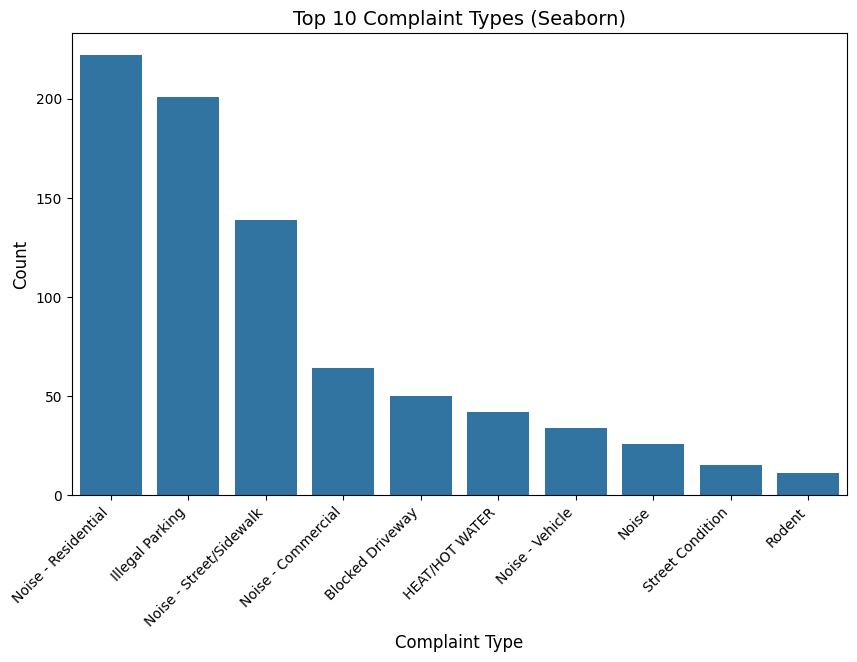

In [13]:
# Convert top complaints to dataframe
top_df = top_complaints.reset_index()
top_df.columns = ['complaint_type', 'count']

# Seaborn bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=top_df, x='complaint_type', y='count')

plt.title("Top 10 Complaint Types (Seaborn)", fontsize=14)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.show()

### Matplotlib vs Seaborn

Matplotlib provides more control and flexibility when creating visualizations, but it requires more code to customize plots. In this assignment, I used matplotlib to manually adjust properties such as colors, labels, markers, and grid lines.

Seaborn, on the other hand, is built on top of matplotlib and provides a simpler and more visually appealing way to create plots. It requires less code and automatically applies better styling. However, it offers slightly less control compared to matplotlib.

Overall, matplotlib is better for full customization, while seaborn is better for quick and clean visualizations.

## Conclusion

By exploring the NYC 311 dataset, I identified patterns in how complaints are reported over time and which types appear most frequently. The visualizations made it easier to understand trends that would not be obvious from raw data alone. For example, grouping complaints by month show how complaint activity changes over time, and the bar chart highlighted the most common complaint types.

From what I understand, working with both matplotlib and seaborn helped me see the difference between building visualizations from scratch versus using tools that simplify the process. Matplotlib gives more control and flexibility, but it requires more code to adjust and customize each part of the plot. Seaborn, on the other hand, makes it easier to create clean and visually appealing charts with less effort by working directly with the dataset structure.

Overall, this assignment helped me better understand how to work with real-world data, create meaningful visualizations, and choose the right tools for the situation. It also reinforced that visualization is an important part of data analysis because it helps turn data into insights that are easier to interpret and explain.


